In [ ]:
!pip install optuna
!pip install mlflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler

import mlflow

import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85

In [ ]:
X = pd.read_csv('A.csv')
y = pd.read_csv('A_targets.csv')

df = pd.concat([X, y], axis=1)
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,Student_ID,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,6.5,8,Yes,Medium,Tier 2,Yes,Medium,1,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,7.1,8,Yes,Medium,Tier 3,Yes,Low,2,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6.1,2,No,Low,Tier 2,Yes,High,3,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,7.3,7,No,Medium,Tier 1,Yes,Low,4,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,6.0,7,No,Medium,Tier 1,Yes,Medium,5,Placed,15.91


In [ ]:
df.shape

(5000, 26)

In [ ]:
df.describe()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,Student_ID,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,2500.500000,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,1443.520003,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,1250.750000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,2500.500000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,3750.250000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,5000.000000,20.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [ ]:
df = df.drop(columns=["Student_ID"])

# 1. Workflow

## Missing Value handling

In [ ]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage (%)
gender,0,0.00
branch,0,0.00
cgpa,0,0.00
tenth_percentage,0,0.00
twelfth_percentage,0,0.00
backlogs,0,0.00
study_hours_per_day,0,0.00
attendance_percentage,0,0.00
projects_completed,0,0.00
internships_completed,0,0.00


Terdapat 20% data yang tidak terisi di kolom 'extracurricular_involvement' yang kalau diimputasi sembarangan akan menyebabkan nilai bias dan kesalahan lain. Untuk menghandle ini, saya juga tidak mau melakukan drop karena data-data lain masih penting. Saya memutuskan untuk mengubah semua missing values menjadi value baru bernama 'unknown'. Sebelum modelling nanti, saya akan mengecek apakah kolom ini memiliki pengaruh yang signifikan terhadap kedua target.

In [ ]:
df["extracurricular_involvement"] = df["extracurricular_involvement"].fillna("Unknown")
df['extracurricular_involvement'].value_counts()

,count
extracurricular_involvement,
Medium,1501
Low,1485
High,1008
Unknown,1006


In [ ]:
df.duplicated().sum()

np.int64(0)

## Target Analysis

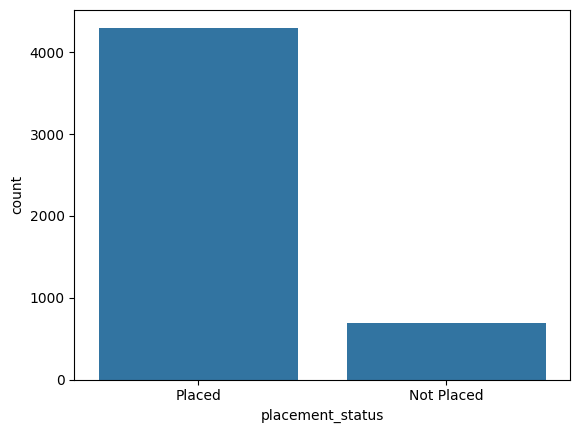

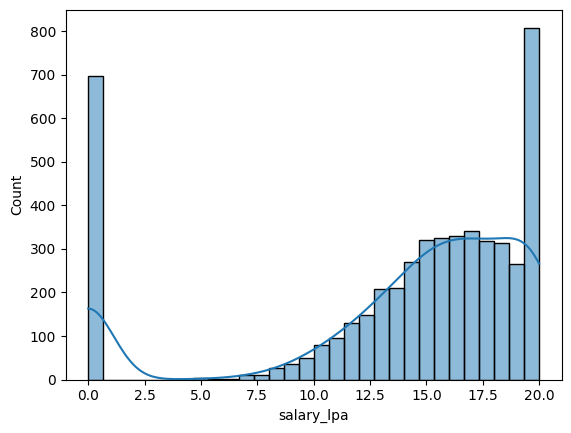

In [ ]:
sns.countplot(x="placement_status", data=df)
plt.show()

sns.histplot(df["salary_lpa"], kde=True)
plt.show()

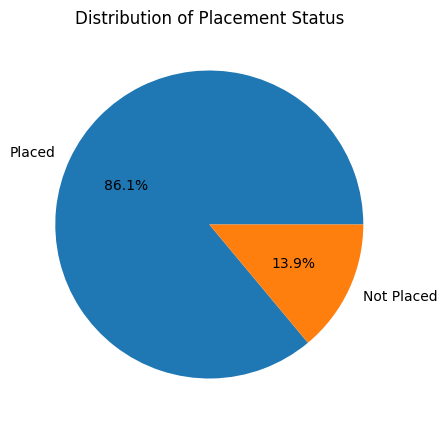

In [ ]:
df['placement_status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.title("Distribution of Placement Status")
plt.ylabel("")
plt.show()

Target placement_status menunjukkan class imbalance. Dapat dilihat bahwa mayoritas mahasiswa berhasil ditempatkan 86% sedangkan yang tidak keterima ada sebanyak 14%. Hal ini akan menghasilkan model yang bias sehingga handling balance diperlukan saat modelling klasifikasi.


 Dilihat dari grafik salary, sebagian besar nilai salary ada di angka yang cenderung tinggi, sekitar 12 sampai 20. Tapi anehnya, ada juga yang nilainya 0. Jadi bisa disimpulkan bahwa distribusinya tidak rata dan tidak berbentuk normal, karena menumpuk di dua bagian.

### Klasifikasi

#### Categorical

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts(normalize=True))

gender
Male      0.5998
Female    0.4002
Name: proportion, dtype: float64
branch
CSE    0.3044
ECE    0.2672
IT     0.1926
ME     0.1450
CE     0.0908
Name: proportion, dtype: float64
part_time_job
No     0.8014
Yes    0.1986
Name: proportion, dtype: float64
family_income_level
Medium    0.4932
Low       0.3006
High      0.2062
Name: proportion, dtype: float64
city_tier
Tier 2    0.4046
Tier 3    0.3094
Tier 1    0.2860
Name: proportion, dtype: float64
internet_access
Yes    0.8922
No     0.1078
Name: proportion, dtype: float64
extracurricular_involvement
Medium     0.3002
Low        0.2970
High       0.2016
Unknown    0.2012
Name: proportion, dtype: float64
placement_status
Placed        0.8606
Not Placed    0.1394
Name: proportion, dtype: float64


Kebanyakan kategori di data ini bersifat imbalance. Bahkan ada yang perbedaannya terlihat signifikan seperti internet_access.

extracurricular_involvement juga memiliki value baru akibat imputasi yang dilakukan sebelum ini.

#### Numerikal

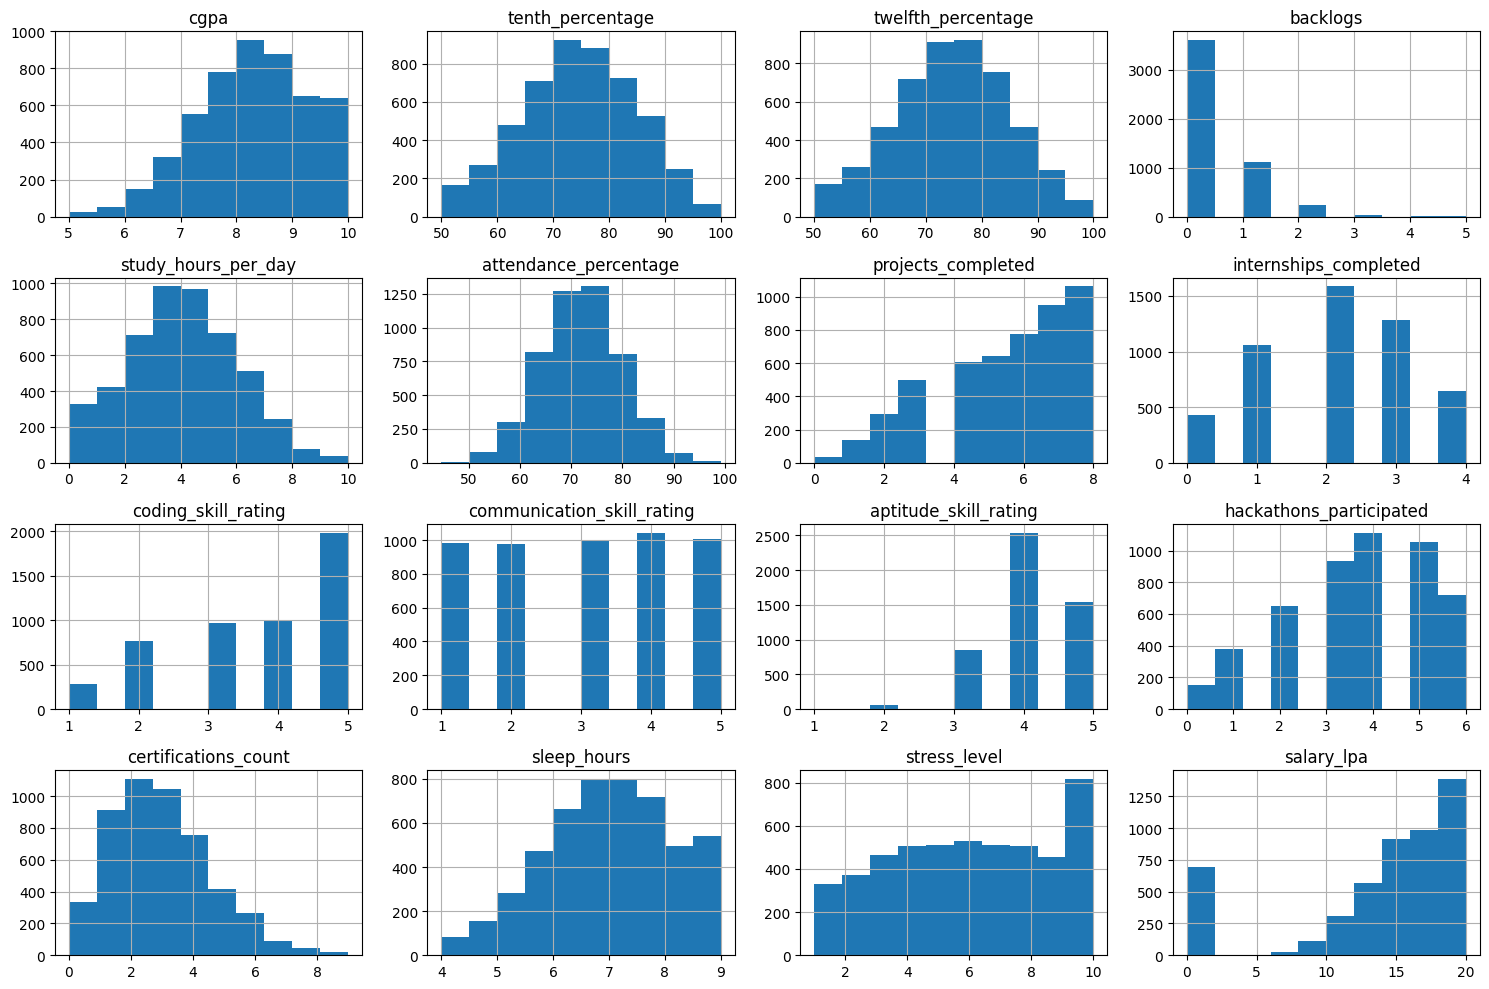

In [ ]:
df.select_dtypes(include='number').hist(figsize=(15,10))
plt.tight_layout()
plt.show()

Secara keseluruhan sebagian besar memiliki distribusi yang bisa dibilang cukup normal dan mendekati normal, tetapi ada eberapa yang masih skewed. Contoh distribusi yang normal adalah study hours per day, study hours per day, dan lain-lain, dapat dilihat bahwa fitur-fitur itu memiliki data yang berdistribusi secara normal. Berbeda dengan backlogs atau certifications count dimana kita bisa melihat bahwa datanya skew.

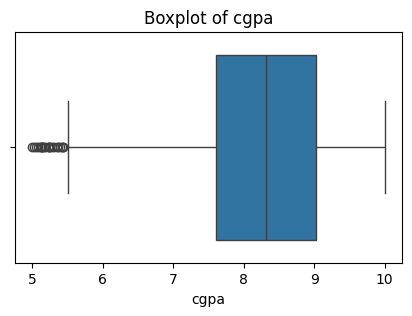

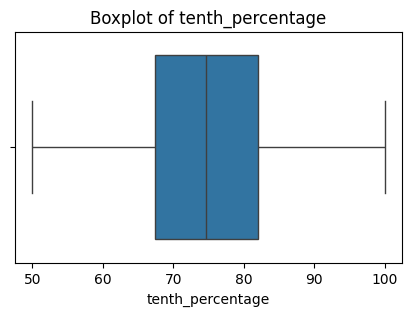

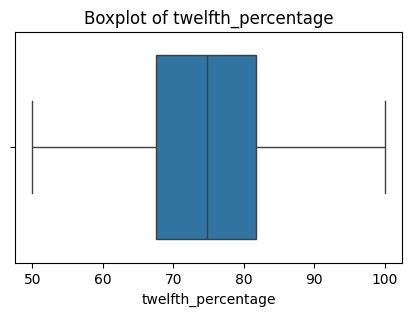

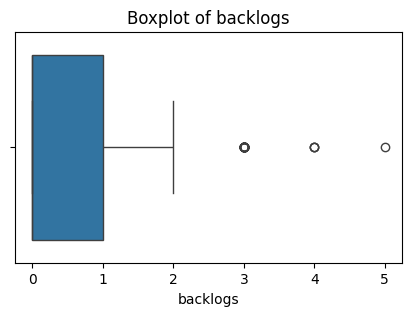

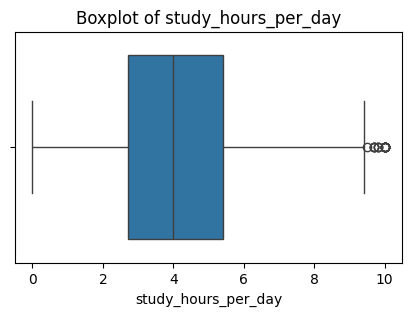

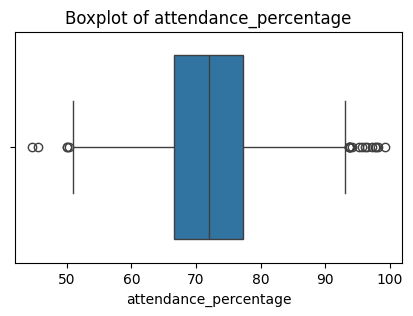

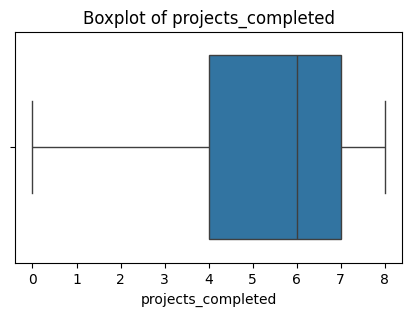

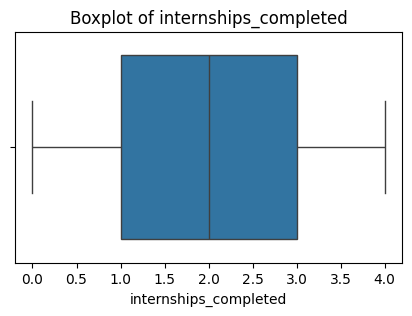

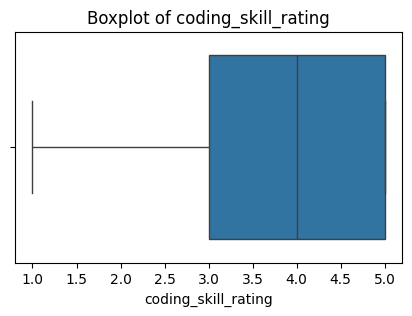

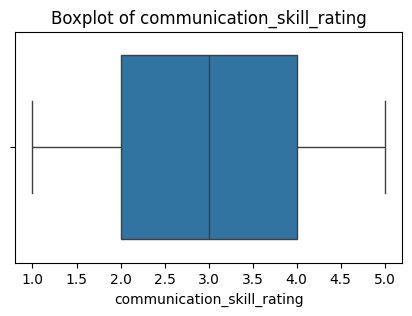

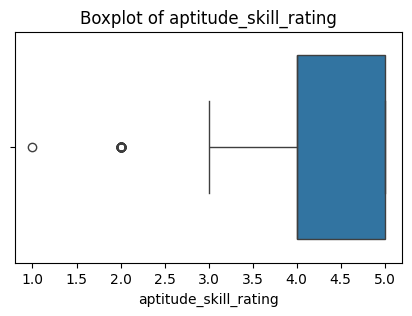

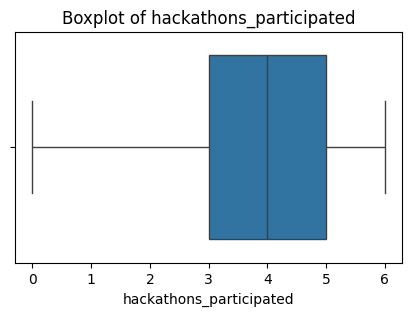

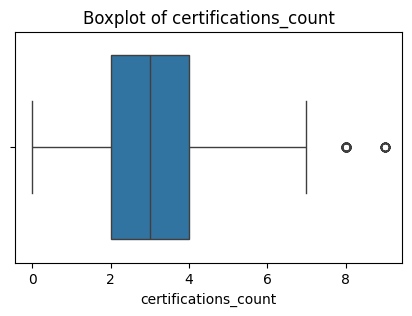

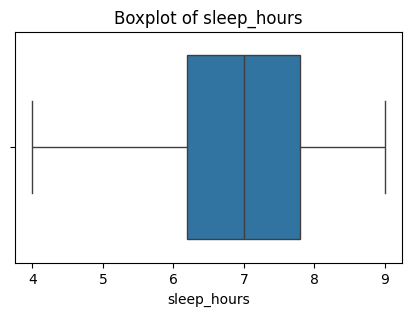

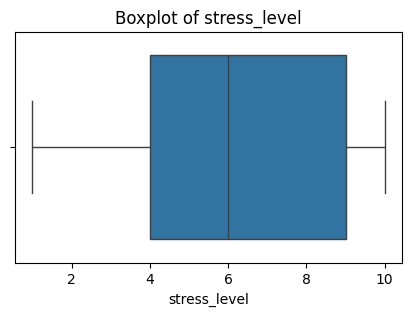

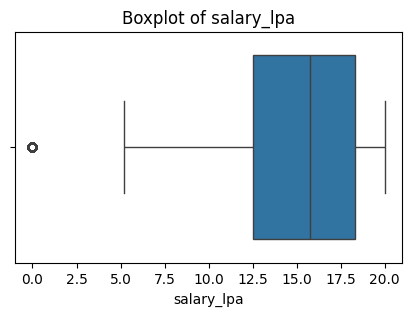

In [ ]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Terdapat beberapa outlier yang bisa kita lihat di boxplot, tapi kebanyakan masuk di logika.

In [ ]:
df.select_dtypes(include='number').skew().sort_values(ascending=False) # melihat skew

,0
backlogs,1.903108
certifications_count,0.637560
study_hours_per_day,0.106912
attendance_percentage,0.035589
communication_skill_rating,-0.032599
internships_completed,-0.088272
twelfth_percentage,-0.090680
stress_level,-0.134098
tenth_percentage,-0.135032
sleep_hours,-0.171876


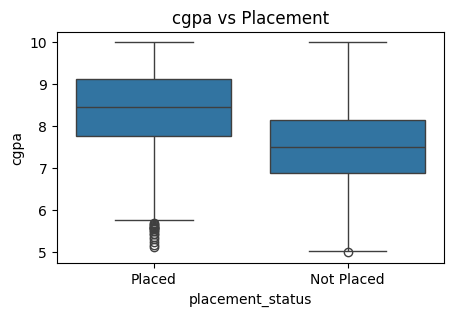

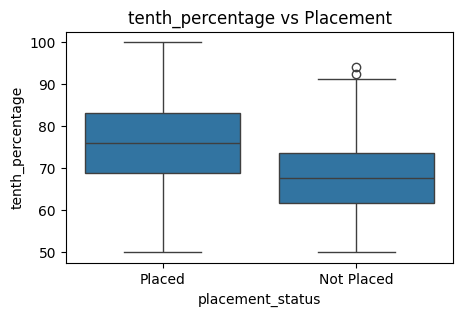

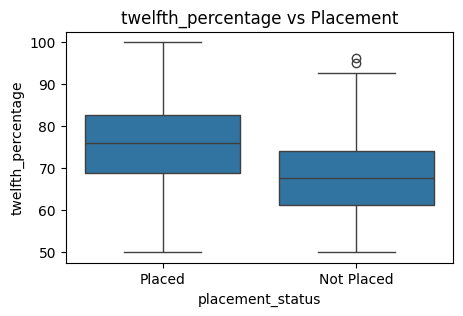

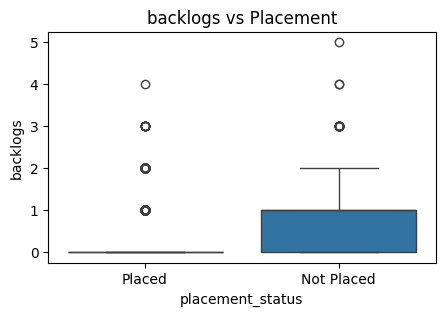

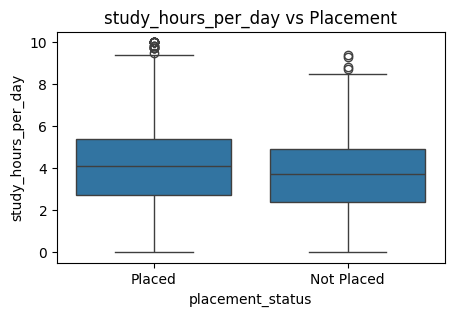

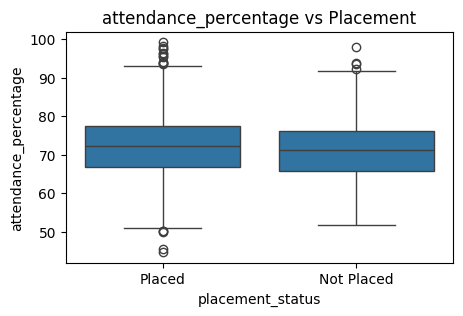

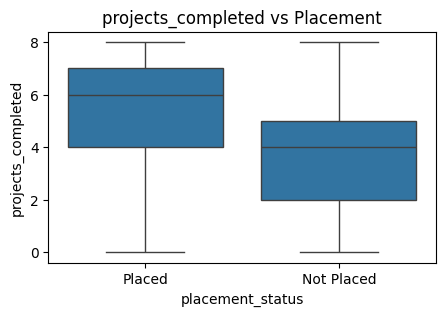

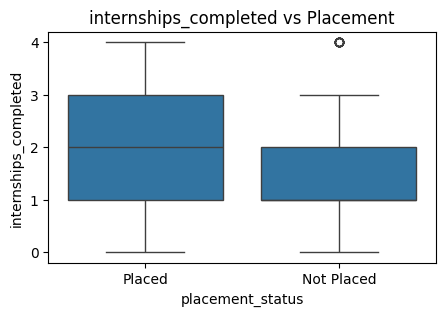

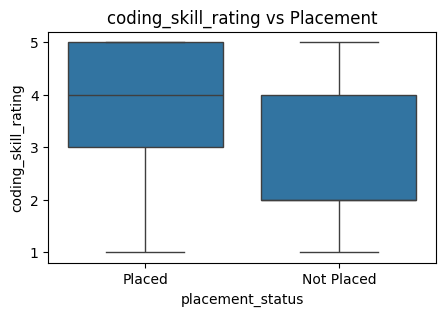

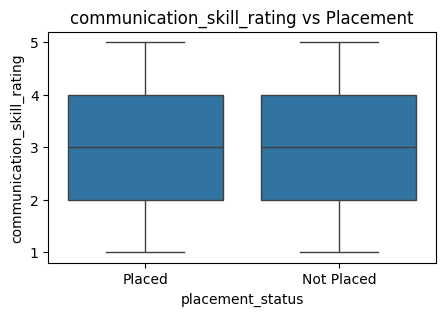

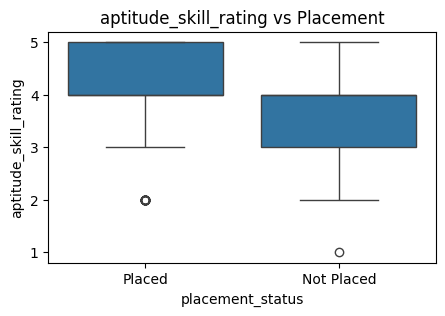

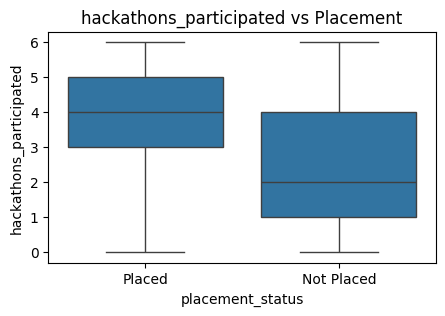

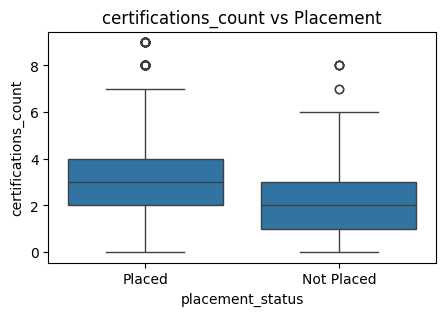

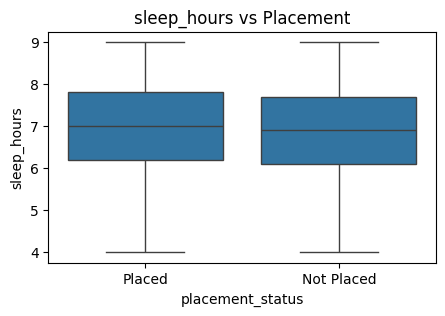

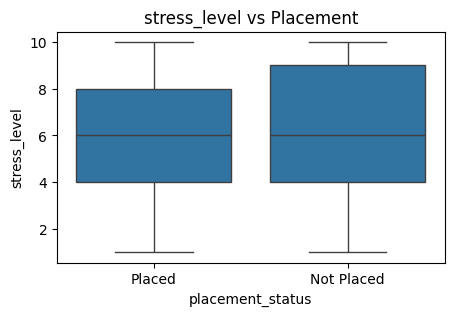

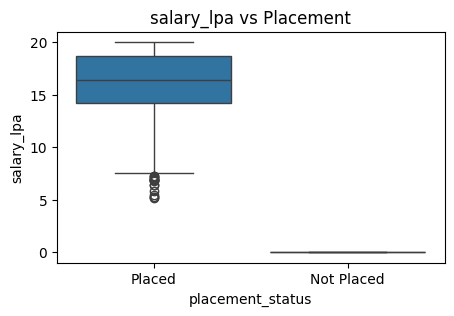

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    if col != "placement_status":
        plt.figure(figsize=(5,3))
        sns.boxplot(x="placement_status", y=col, data=df)
        plt.title(f"{col} vs Placement")
        plt.show()

Dari hasil analisis hubungan antara fitur numerik dan placement_status, ditemukan bahwa beberapa fitur menunjukkan perbedaan distribusi yang signifikan antara mahasiswa yang placed dan tidak placed. Fitur seperti CGPA, jumlah proyek (projects_completed), jumlah internship (internships_completed), serta skill seperti coding dan aptitude memiliki nilai yang lebih tinggi pada mahasiswa yang berhasil mendapatkan placement. Tetapifitur backlog menunjukkan hubungan negatif, di mana mahasiswa yang tidak placed cenderung memiliki jumlah backlog yang lebih tinggi.

Beberapa fitur lain seperti communication skill, sleep hours, dan stress level tidak menunjukkan perbedaan yang signifikan, sehingga kemungkinan memiliki pengaruh yang lebih kecil terhadap hasil placement.

### Regresi

#### Numerikal

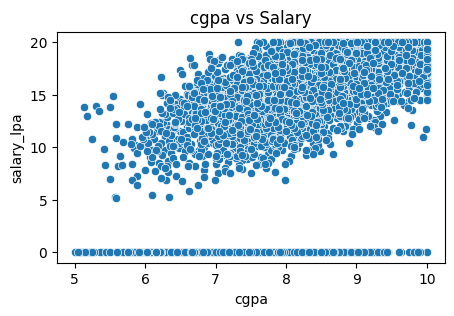

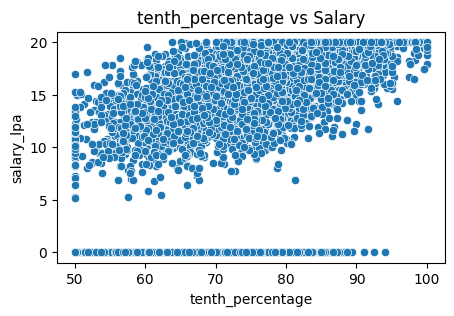

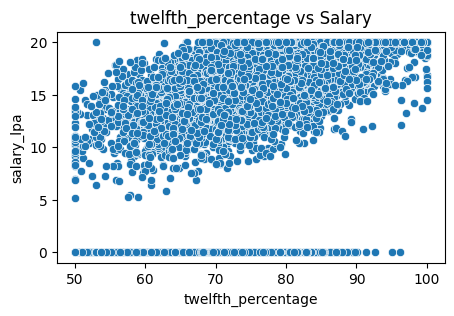

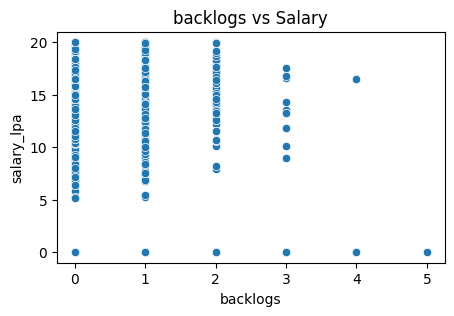

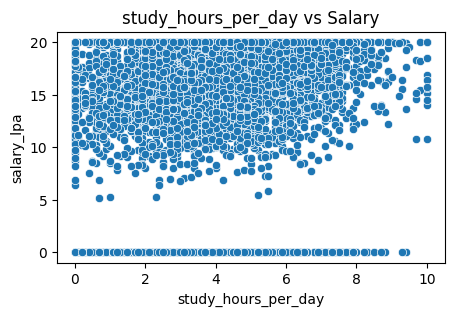

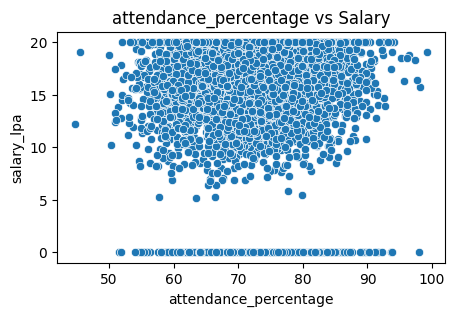

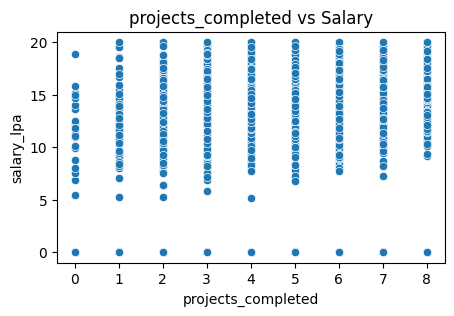

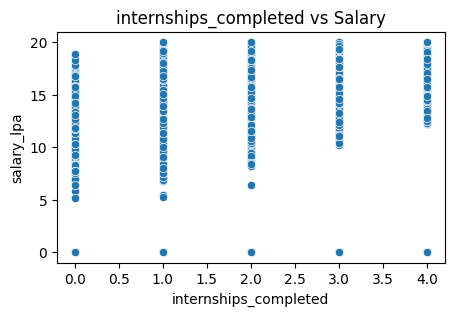

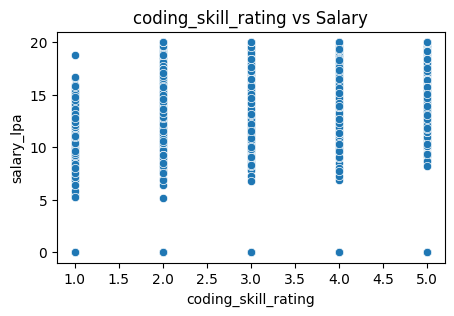

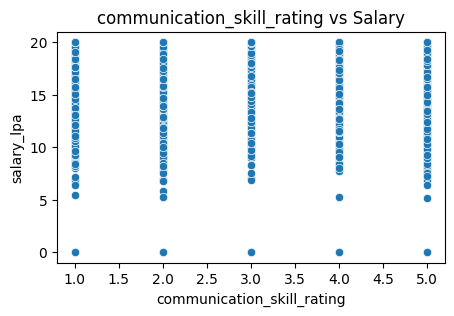

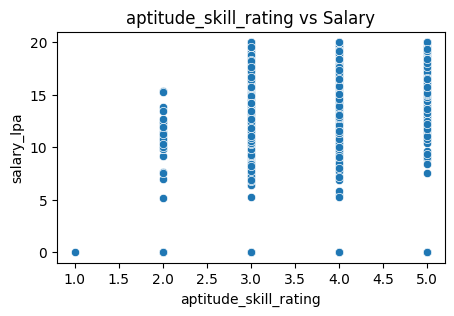

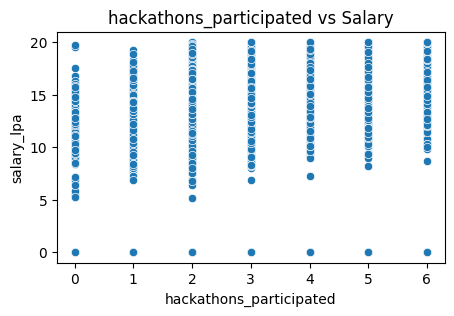

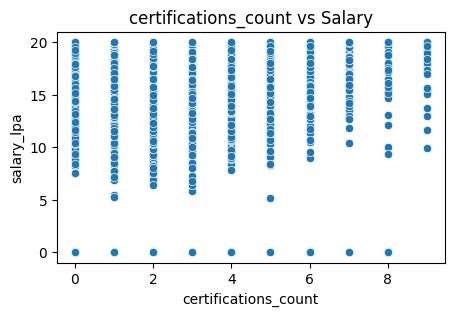

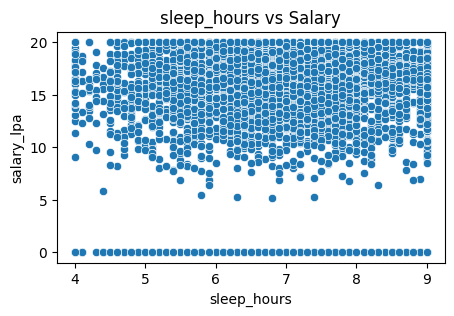

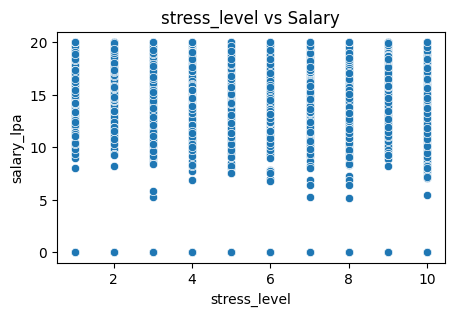

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    if col != "salary_lpa":
        plt.figure(figsize=(5,3))
        sns.scatterplot(x=df[col], y=df['salary_lpa'])
        plt.title(f"{col} vs Salary")
        plt.show()

Berdasarkan scatter plot di atas, fitur akademik seperti CGPA dan academic performance menunjukkan hubungan yang paling kuat terhadap salary. Selain itu, pengalaman seperti internships dan projects juga berkontribusi positif terhadap peningkatan gaji. Sebaliknya, faktor seperti backlog memiliki pengaruh negatif. lifestyle seperti sleep dan stress tidak menunjukkan hubungan yang signifikan

#### Kategorikal

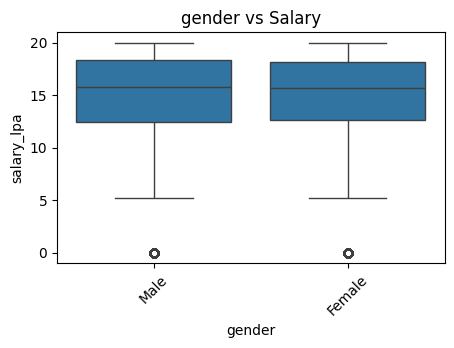

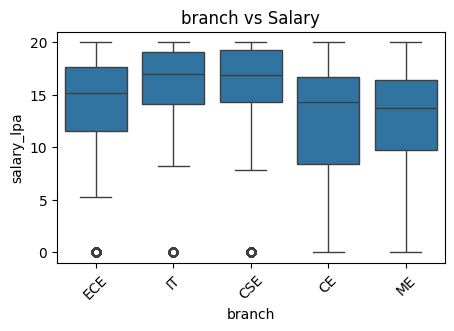

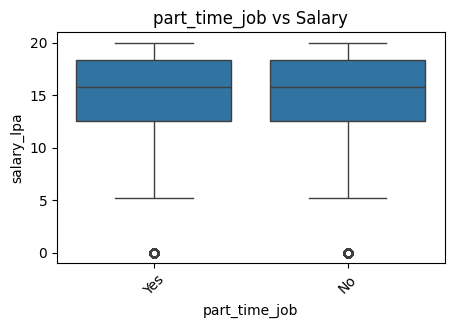

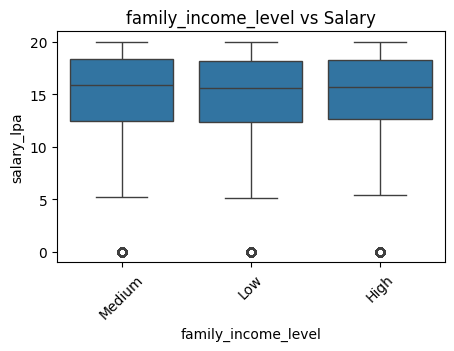

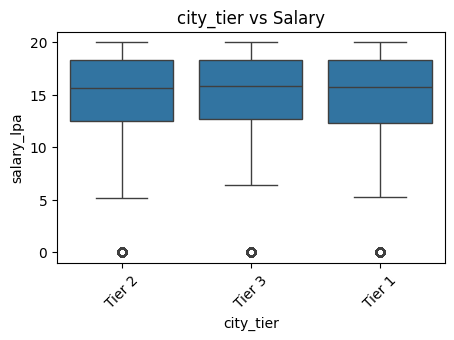

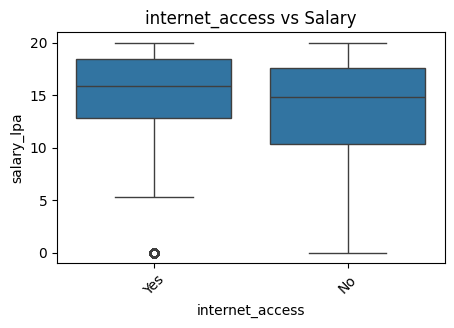

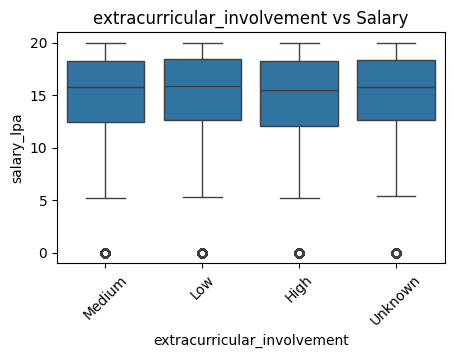

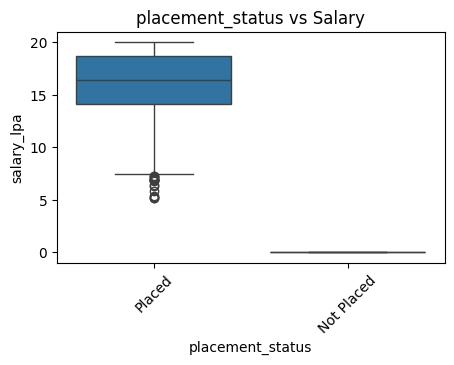

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=col, y='salary_lpa', data=df)
    plt.title(f"{col} vs Salary")
    plt.xticks(rotation=45)
    plt.show()

Analisis variabel kategorikal VS salary menunjukkan bahwa sebagian besar fitur seperti gender dan part-time job tidak memiliki pengaruh signifikan terhadap salary. Namun, faktor seperti branch, internet access, dan extracurricular involvement menunjukkan kecenderungan hubungan terhadap peningkatan gaji.


Variabel placement_status memiliki hubungan yang sangat kuat dengan salary, sehingga tidak digunakan dalam model regresi untuk menghindari data leakage.

## Correlation Checks

### Klasifikasi

#### Numerikal

Untuk menganalisa hubungan antara fitur numerik dan placement status yang merupakan kategorikal, saya akan mengubah placement_status menjadi binary untuk sementara.

In [ ]:
df['placement_status_num'] = df['placement_status'].map({
    'Placed': 1,
    'Not Placed': 0
})

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

corr_placement = df[num_cols].corr()['placement_status_num'].sort_values(ascending=False)
print(corr_placement)

placement_status_num          1.000000
salary_lpa                    0.895356
coding_skill_rating           0.343219
projects_completed            0.322796
cgpa                          0.315614
hackathons_participated       0.275848
tenth_percentage              0.269680
twelfth_percentage            0.268454
internships_completed         0.254189
aptitude_skill_rating         0.213778
certifications_count          0.125657
communication_skill_rating    0.074704
study_hours_per_day           0.065022
attendance_percentage         0.042426
sleep_hours                   0.016469
stress_level                 -0.045556
backlogs                     -0.415297
Name: placement_status_num, dtype: float64


In [ ]:
df = df.drop(columns=['placement_status_num'])

Bisa kita lihat disini bahwa ada yang menunjukkan persentase informasi yang sama, hal ini disebut redundan maka harus pilih salah satu. Saya akan memilih nilai akhir untuk dipertahankan (twelfth). Sedangkan walaupun projects completed dan cgpa sama, secara logika dua hal ini berbeda

p < 0.05 tidak signifikan

p > 0.05 signifikan

salary_lpa tentu saja memiliki korelasi yang kuat dan dapat menyebabkan overfitting.

columns to drop :

- sleep_hours

- attendance_percentage

- study_hours_per_day

- communication_skill_rating

- stress_level

- salary


#### Kategorikal

In [ ]:
from scipy.stats import chi2_contingency

for col in df.select_dtypes(include='object').columns:
    if col != 'placement_status':
        table = pd.crosstab(df[col], df['placement_status'])
        chi2, p, dof, ex = chi2_contingency(table)
        print(f"{col} → p-value: {p}")

gender → p-value: 0.9627371251385962
branch → p-value: 3.0447376742023646e-20
part_time_job → p-value: 0.6879606791076409
family_income_level → p-value: 0.9848957798119644
city_tier → p-value: 0.8752289479452433
internet_access → p-value: 0.00018829244783839926
extracurricular_involvement → p-value: 0.47772452711433555


p-value < 0.05  

p-value > 0.05

columns to drop:

- gender

- part_time_job

- family_income_level

- city_tier

- extracurricular_involvement

### Regresi

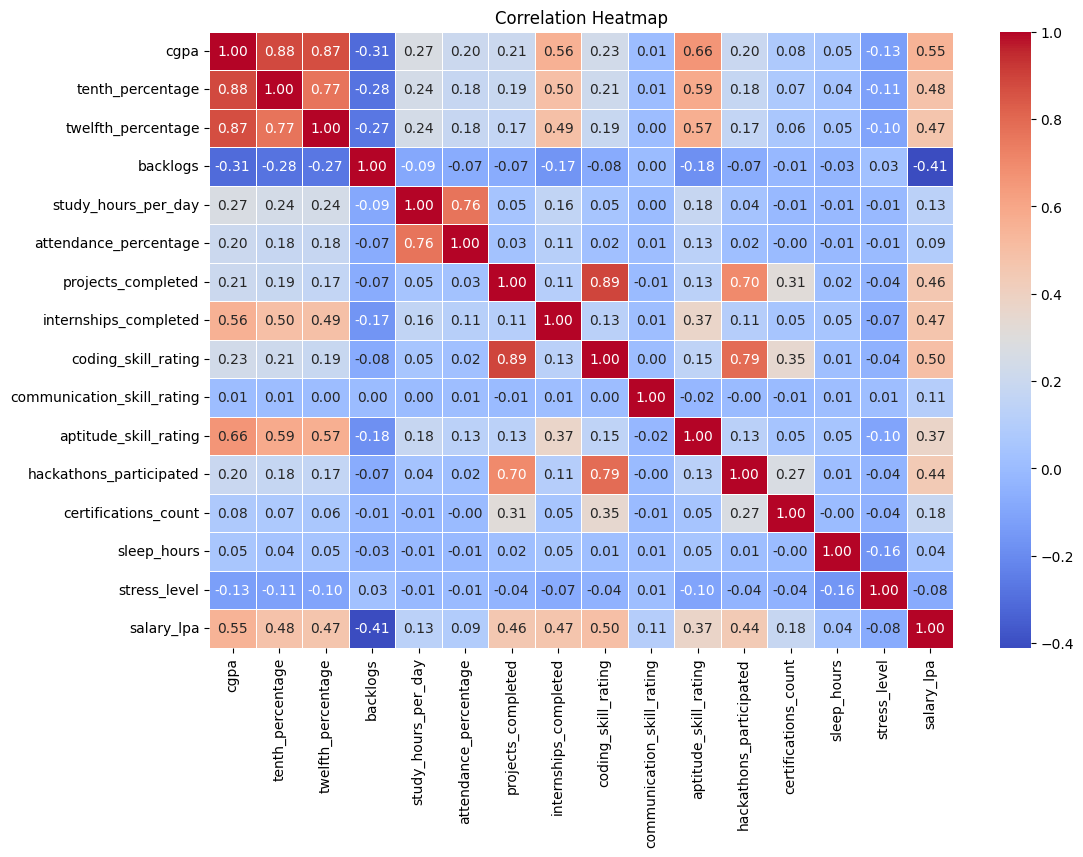

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Dari heatmap ini, kita bisa lihat kalau misalnya gaada data yang benar-benar kuat dengan salary kecuali backlogs, itupun hanya ada satu, yang lainnya lemah dan ada juga yang sangat lemah. Hal ini akan berdampak kepada hasil akhir model karena tidak banyak fitur yang cukup kuat.

#### Numerikal

In [ ]:
corr_salary = df.corr(numeric_only=True)['salary_lpa'].sort_values(ascending=False)
print(corr_salary)

salary_lpa                    1.000000
cgpa                          0.549533
coding_skill_rating           0.496776
tenth_percentage              0.481920
twelfth_percentage            0.471026
internships_completed         0.469054
projects_completed            0.456588
hackathons_participated       0.438845
aptitude_skill_rating         0.372738
certifications_count          0.180561
study_hours_per_day           0.132681
communication_skill_rating    0.105519
attendance_percentage         0.091106
sleep_hours                   0.037290
stress_level                 -0.077133
backlogs                     -0.410192
Name: salary_lpa, dtype: float64


columns to drop:

- sleep_hours

- attendance_percentage

- stress_level

- tenth_percentage

#### kategorikal

In [ ]:
from scipy.stats import f_oneway

for col in df.select_dtypes(include='object').columns:
    if col != 'placement_status':
        groups = [group['salary_lpa'].values for name, group in df.groupby(col)]
        stat, p = f_oneway(*groups)
        print(f"{col} → p-value: {p}")

gender → p-value: 0.7359520503225425
branch → p-value: 1.3905278178892636e-62
part_time_job → p-value: 0.7148426422850263
family_income_level → p-value: 0.8291344756771928
city_tier → p-value: 0.8852521877763359
internet_access → p-value: 1.5532107499194712e-08
extracurricular_involvement → p-value: 0.5204121896295874


columns to drop:

- gender

- part_time_job

- extracurricular_involvement

- communication skill rating

- family income

## Feature Engineering

Saya akan melakukan feature engineering dengan menggabungkan beberapa variabel yang memiliki kesamaan menjadi fitur baru seperti academic_score, experience_score, dan skill_score, dengan tujuan meningkatkan representasi dan membantu model untuk menangkap pola yang lebih kompleks.

In [ ]:
df['academic_score'] = (
    df['cgpa'] * 0.5 +
    df['twelfth_percentage'] * 0.25
)

df['experience_score'] = (
    df['internships_completed'] +
    df['projects_completed'] +
    df['hackathons_participated']
)

df['skill_score'] = (
    df['coding_skill_rating'] +
    df['aptitude_skill_rating']
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5000 non-null   object 
 1   branch                       5000 non-null   object 
 2   cgpa                         5000 non-null   float64
 3   tenth_percentage             5000 non-null   float64
 4   twelfth_percentage           5000 non-null   float64
 5   backlogs                     5000 non-null   int64  
 6   study_hours_per_day          5000 non-null   float64
 7   attendance_percentage        5000 non-null   float64
 8   projects_completed           5000 non-null   int64  
 9   internships_completed        5000 non-null   int64  
 10  coding_skill_rating          5000 non-null   int64  
 11  communication_skill_rating   5000 non-null   int64  
 12  aptitude_skill_rating        5000 non-null   int64  
 13  hackathons_partici

## dipisah antara klasifikasi dan regresi

### Klasifikasi - Placement Status

In [ ]:
df['placement_status'] = df['placement_status'].map({
    'Not Placed': 0,
    'Placed': 1
})

In [ ]:
df_class = df.copy()

X_class = df_class.drop([
    'placement_status',   # target
    'salary_lpa'          # dihapus karena PASTI menyebabkan leak
], axis=1)

y_class = df_class['placement_status']

In [ ]:
# drop fitur - fitur yang tadi di cek dan hasil kolerasinya lemah

X_class = X_class.drop([
    'sleep_hours',
    'attendance_percentage',
    'study_hours_per_day',
    'stress_level',
    'gender',
    'part_time_job',
    'family_income_level',
    'city_tier',
    'extracurricular_involvement',
    'tenth_percentage',
    'communication_skill_rating',
], axis=1, errors='ignore')

In [ ]:
X_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   branch                   5000 non-null   object 
 1   cgpa                     5000 non-null   float64
 2   twelfth_percentage       5000 non-null   float64
 3   backlogs                 5000 non-null   int64  
 4   projects_completed       5000 non-null   int64  
 5   internships_completed    5000 non-null   int64  
 6   coding_skill_rating      5000 non-null   int64  
 7   aptitude_skill_rating    5000 non-null   int64  
 8   hackathons_participated  5000 non-null   int64  
 9   certifications_count     5000 non-null   int64  
 10  internet_access          5000 non-null   object 
 11  academic_score           5000 non-null   float64
 12  experience_score         5000 non-null   int64  
 13  skill_score              5000 non-null   int64  
dtypes: float64(3), int64(9),

In [ ]:
y_class.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: placement_status
Non-Null Count  Dtype
--------------  -----
5000 non-null   int64
dtypes: int64(1)
memory usage: 39.2 KB


### Regresi - Salary

In [ ]:
df_reg = df.copy()

X_reg = df_reg.drop([
    'salary_lpa',        # target
    'placement_status'   # leak
], axis=1)

y_reg = df_reg['salary_lpa']

In [ ]:
X_reg = X_reg.drop([
    'sleep_hours',
    'attendance_percentage',
    'stress_level',
    'gender',
    'part_time_job',
    'city_tier',
    'extracurricular_involvement',
    'family_income_level',
    'communication_skill_rating',
    'tenth_percentage'
], axis=1, errors='ignore')

In [ ]:
X_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   branch                   5000 non-null   object 
 1   cgpa                     5000 non-null   float64
 2   twelfth_percentage       5000 non-null   float64
 3   backlogs                 5000 non-null   int64  
 4   study_hours_per_day      5000 non-null   float64
 5   projects_completed       5000 non-null   int64  
 6   internships_completed    5000 non-null   int64  
 7   coding_skill_rating      5000 non-null   int64  
 8   aptitude_skill_rating    5000 non-null   int64  
 9   hackathons_participated  5000 non-null   int64  
 10  certifications_count     5000 non-null   int64  
 11  internet_access          5000 non-null   object 
 12  academic_score           5000 non-null   float64
 13  experience_score         5000 non-null   int64  
 14  skill_score             

## Split

### Klasifikasi

In [ ]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_class
)

In [ ]:
Xc_train.shape, Xc_test.shape, yc_train.shape, yc_test.shape

((4000, 14), (1000, 14), (4000,), (1000,))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_class.select_dtypes(include=['int64','float64']).columns
cat_cols = X_class.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

Xc_train_enc = preprocessor.fit_transform(Xc_train)
Xc_test_enc = preprocessor.transform(Xc_test)

In [ ]:
y_class.value_counts()

,count
placement_status,
1,4303
0,697


In [ ]:
print(Xc_train_enc.shape)
print(Xc_test_enc.shape)

(4000, 19)
(1000, 19)


### Regresi

In [ ]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [ ]:
yr_train_log = np.log1p(yr_train)

num_cols_reg = X_reg.select_dtypes(include=['int64','float64']).columns
cat_cols_r = X_reg.select_dtypes(include=['object']).columns

preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), num_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_r)
])

Xr_train_enc = preprocessor_reg.fit_transform(Xr_train)
Xr_test_enc = preprocessor_reg.transform(Xr_test)

In [ ]:
Xr_train.shape, Xr_test.shape, yr_train.shape, yr_test.shape

((4000, 15), (1000, 15), (4000,), (1000,))

In [ ]:
print(Xr_train_enc.shape)
print(Xr_test_enc.shape)

(4000, 20)
(1000, 20)


## Modelling

### Klasifikasi

Di bagian awal tadi saat target analysis, dapat dilihat bahwa adanya extreme balance antara placed dan not placed. Hal inilah yang mengharuskan penggunaan imbalance handling, seperti smote atau class weight balanced

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results_weight_cv_full = {}

# MODELS WITH CLASS WEIGHT
models_weight_cv = {
    "LogReg_weight": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    "RF_weight": RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    "XGB_weight": xgb.XGBClassifier(
        scale_pos_weight = (y_class.value_counts()[0] / y_class.value_counts()[1]),
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    )
}

# METRICs
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# CROSS VALIDATION
for name, model in models_weight_cv.items():
    print(f"\n=== {name} ===")

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X_class,
        y_class,
        cv=skf,
        scoring=scoring
    )

    results_weight_cv_full[name] = [
        scores['test_accuracy'].mean(),
        scores['test_precision'].mean(),
        scores['test_recall'].mean(),
        scores['test_f1'].mean()
    ]

# FINAL TABLE
results_weight_cv_full_df = pd.DataFrame(
    results_weight_cv_full,
    index=['Accuracy', 'Precision', 'Recall', 'F1']
).T

print("\n=== FINAL CV RESULTS (CLASS WEIGHT) ===")
print(results_weight_cv_full_df)


=== LogReg_weight ===

=== RF_weight ===

=== XGB_weight ===

=== FINAL CV RESULTS (CLASS WEIGHT) ===
               Accuracy  Precision    Recall        F1
LogReg_weight    0.8216   0.968932  0.818957  0.887573
RF_weight        0.8808   0.898509  0.971183  0.933427
XGB_weight       0.8538   0.940196  0.886586  0.912542


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedKFold, cross_validate

smote = SMOTE(random_state=RANDOM_STATE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results_smote_cv_full = {}

models_smote_cv = {
    "LogReg_SMOTE": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RF_SMOTE": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGB_SMOTE": xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

# metrics yang mau diambil
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

for name, model in models_smote_cv.items():
    print(f"\n=== {name} ===")

    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X_class,
        y_class,
        cv=skf,
        scoring=scoring
    )

    results_smote_cv_full[name] = [
        scores['test_accuracy'].mean(),
        scores['test_precision'].mean(),
        scores['test_recall'].mean(),
        scores['test_f1'].mean()
    ]

# jadi dataframe
results_smote_cv_full_df = pd.DataFrame(
    results_smote_cv_full,
    index=['Accuracy', 'Precision', 'Recall', 'F1']
).T

print("\n=== FINAL CV RESULTS (WITH SMOTE) ===")
print(results_smote_cv_full_df)


=== LogReg_SMOTE ===

=== RF_SMOTE ===

=== XGB_SMOTE ===

=== FINAL CV RESULTS (WITH SMOTE) ===
              Accuracy  Precision    Recall        F1
LogReg_SMOTE    0.8244   0.968296  0.822908  0.889609
RF_SMOTE        0.8742   0.923472  0.930976  0.927190
XGB_SMOTE       0.8732   0.914967  0.940038  0.927304


Saya sudah mencoba untuk melakukan handling imbalance menggunakan kedua cara, yaitu smote dan weightclass. Hasil yang saya dapatkan adalah

1. Pada akurasi, smote memiliki persentase yang lebih tinggi daripada weightclass walaupun perbedaannya sangat keci. Tapi perlu diingat, untuk kasus ini (imbalance data), accuracy bukanlah metric yang reliable karena bisa saja model terlihat bagus karena adanya mayoritas yang dominan.

2. Di precision (yang benar-benar placed) smote menjadi lebih tertutup (terlalu banyak filtering) sehingga model jarang memberi label placed pada data dan berpotensi melewatkan data yang harusnya 'paced'.

3. Recall adalah metrik atau indikator yang penting disini. Disini class weight memiliki persentasi yang lebih unggul. Model hampir tidak melewatkan kandidat yang sebenarnya placed. Di Random Forest Weight (0.97) > SMOTE (0.93)

4. F1-Score juga menjadi indikator utama disini. Bisa dilihta bahwa persentase di weight balance lebih tinggi (karena recall weight > smote)

Setelah menganalisa, saya memutuskan untuk memakai model yang dihandle menggunakan weight-class imbalance. (0.93 > 0.92)

In [ ]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

RANDOM_STATE = 42
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# CLASS WEIGHT
classes = np.unique(y_class)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_class)
class_weight_dict = dict(zip(classes, weights))

neg, pos = np.bincount(y_class)
scale_pos_weight = neg / pos

# OBJECTIVE FUNCTIONS

# Logistic Regression
def objective_lr(trial):
    C = trial.suggest_float("C", 0.01, 10, log=True)
    use_weight = trial.suggest_categorical("class_weight", [None, "balanced", "custom"])

    if use_weight == "custom":
        cw = class_weight_dict
    else:
        cw = use_weight

    model = LogisticRegression(C=C, max_iter=1000, class_weight=cw)

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    score = cross_val_score(pipe, X_class, y_class, cv=skf, scoring='f1').mean()
    return score


# Random Forest
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_categorical("max_depth", [None, 5, 10])
    use_weight = trial.suggest_categorical("class_weight", [None, "balanced", "custom"])

    if use_weight == "custom":
        cw = class_weight_dict
    else:
        cw = use_weight

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight=cw,
        random_state=RANDOM_STATE
    )

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    score = cross_val_score(pipe, X_class, y_class, cv=skf, scoring='f1').mean()
    return score


# XGBoost
def objective_xgb(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 3, 6)
    lr = trial.suggest_float("learning_rate", 0.01, 0.2)
    spw = trial.suggest_categorical("scale_pos_weight", [1, scale_pos_weight])

    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    score = cross_val_score(pipe, X_class, y_class, cv=skf, scoring='f1_macro').mean()
    return score

# RUN OPTUNA
print("\n=== OPTUNA TUNING ===")

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=20)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

# RESULTS
print("\n=== BEST RESULTS ===")

print("\nLogisticRegression")
print("Best Params:", study_lr.best_params)
print("Best F1:", study_lr.best_value)

print("\nRandomForest")
print("Best Params:", study_rf.best_params)
print("Best F1:", study_rf.best_value)

print("\nXGBoost")
print("Best Params:", study_xgb.best_params)
print("Best F1:", study_xgb.best_value)

[I 2026-04-22 08:08:27,311] A new study created in memory with name: no-name-ce5c719b-b3e6-4781-aee6-140ab89edf3b



=== OPTUNA TUNING ===


[I 2026-04-22 08:08:27,548] Trial 0 finished with value: 0.885865628931322 and parameters: {'C': 0.010861741738869375, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.885865628931322.
[I 2026-04-22 08:08:27,833] Trial 1 finished with value: 0.8875256984630109 and parameters: {'C': 0.3294885354323313, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8875256984630109.
[I 2026-04-22 08:08:28,123] Trial 2 finished with value: 0.8875256984630109 and parameters: {'C': 0.36221736374373187, 'class_weight': 'custom'}. Best is trial 1 with value: 0.8875256984630109.
[I 2026-04-22 08:08:28,361] Trial 3 finished with value: 0.8876878773326208 and parameters: {'C': 0.030688805550657908, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.8876878773326208.
[I 2026-04-22 08:08:28,608] Trial 4 finished with value: 0.9390739111153629 and parameters: {'C': 0.3703367789211989, 'class_weight': None}. Best is trial 4 with value: 0.9390739111153629.
[I 2026-04-22 08:08:28,858] Tr


=== BEST RESULTS ===

LogisticRegression
Best Params: {'C': 0.13320829612487253, 'class_weight': None}
Best F1: 0.93955350133612

RandomForest
Best Params: {'n_estimators': 257, 'max_depth': 10, 'class_weight': None}
Best F1: 0.9356420863838919

XGBoost
Best Params: {'n_estimators': 214, 'max_depth': 5, 'learning_rate': 0.11144398128405364, 'scale_pos_weight': np.float64(0.16198001394376016)}
Best F1: 0.7363663351773146


semua model performanya hampir sama, bahkan Logistic Regression yang paling simpel justru paling bagus. Artinya data ini polanya tidak terlalu rumit.

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

results_list = []
best_lr_params = study_lr.best_params
best_rf_params = study_rf.best_params
best_xgb_params = study_xgb.best_params

classification_models = {
    "LogisticRegression": LogisticRegression(
        C=best_lr_params['C'],
        class_weight=best_lr_params['class_weight'],
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=best_rf_params['n_estimators'],
        max_depth=best_rf_params['max_depth'],
        class_weight=best_rf_params['class_weight'],
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=best_xgb_params['n_estimators'],
        max_depth=best_xgb_params['max_depth'],
        learning_rate=best_xgb_params['learning_rate'],
        scale_pos_weight=best_xgb_params['scale_pos_weight'],
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )
}

for name, model_instance in classification_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_instance)
    ])

    pipe.fit(Xc_train, yc_train)
    y_prob = pipe.predict_proba(Xc_test)[:, 1]

    # Store results
    results_list.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(yc_test, y_prob)
    })

results_df = pd.DataFrame(results_list)
print(results_df)


                Model   ROC-AUC
0  LogisticRegression  0.914195
1        RandomForest  0.905856
2             XGBoost  0.893858


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    print(f"\n===== {name} =====")
    y_prob = model.predict_proba(X_test)[:, 1]

    # Apply threshold
    y_pred = (y_prob > threshold).astype(int)

    # ROC-AUC
    roc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

    print("\nConfusion Matrix:")
    print(cm_df)

pipe_lr.fit(Xc_train, yc_train)
pipe_rf.fit(Xc_train, yc_train)
pipe_xgb.fit(Xc_train, yc_train)

evaluate_model("Logistic Regression (default 0.5)", pipe_lr, Xc_test, yc_test, threshold=0.5)
evaluate_model("Logistic Regression (threshold 0.3)", pipe_lr, Xc_test, yc_test, threshold=0.3)

evaluate_model("Random Forest", pipe_rf, Xc_test, yc_test, threshold=0.5)

evaluate_model("XGBoost", pipe_xgb, Xc_test, yc_test, threshold=0.5)


===== Logistic Regression (default 0.5) =====
ROC-AUC: 0.9140

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.40      0.50       139
           1       0.91      0.97      0.94       861

    accuracy                           0.89      1000
   macro avg       0.79      0.68      0.72      1000
weighted avg       0.88      0.89      0.88      1000


Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           55           84
Actual 1           26          835

===== Logistic Regression (threshold 0.3) =====
ROC-AUC: 0.9140

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.27      0.40       139
           1       0.89      0.99      0.94       861

    accuracy                           0.89      1000
   macro avg       0.83      0.63      0.67      1000
weighted avg       0.88      0.89      0.86      1000


Confusion Matrix:
          Predicted 0  Pred

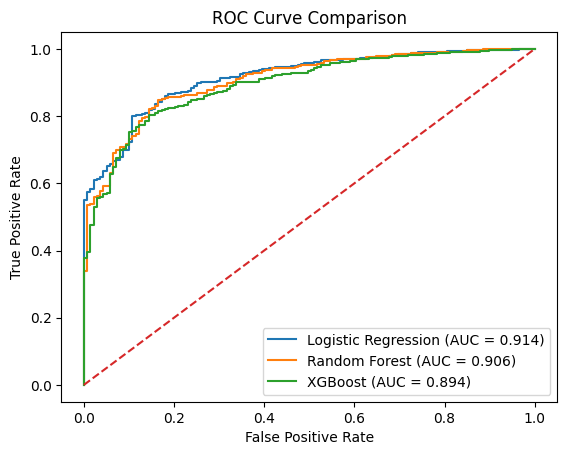

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = pipe_lr.predict_proba(Xc_test)[:, 1]
y_prob_rf = pipe_rf.predict_proba(Xc_test)[:, 1]
y_prob_xgb = pipe_xgb.predict_proba(Xc_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(yc_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(yc_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(yc_test, y_prob_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

Berdasarkan hasil evaluasi, terlihat bahwa Random Forest memiliki performa yang cukup baik pada confusion matrix, terutama dengan jumlah error yang relatif kecil dan distribusi prediksi yang lebih seimbang pada threshold default. Namun, Logistic Regression menunjukkan nilai ROC-AUC tertinggi sebesar 0.914, yang menandakan kemampuan yang lebih baik dalam membedakan kelas positif dan negatif.

Oleh karena itu, meskipun secara confusion matrix Random Forest terlihat lebih stabil, Logistic Regression dipilih sebagai model terbaik karena memiliki kombinasi performa yang kuat dalam hal diskriminasi (ROC-AUC)

Alasan pemilihan Logistic Regression
* Kompleksitas model justru tidak memberikan peningkatan performa yang signifikan
* Bahkan berpotensi menangkap noise (overfitting ringan)

### Regresi

#### Baseline

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
import pandas as pd

RANDOM_STATE = 42

kf_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results_reg_cv = {}

# MODELS
models_reg = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

# METRICS
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# CROSS VALIDATION
for name, model in models_reg.items():
    print(f"\n=== {name} ===")

    pipe = Pipeline([
        ('preprocessor', preprocessor_reg),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X_reg,
        y_reg,
        cv=kf_reg,
        scoring=scoring
    )

    rmse = -scores['test_rmse'].mean()
    mae = -scores['test_mae'].mean()
    r2 = scores['test_r2'].mean()

    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    results_reg_cv[name] = [rmse, mae, r2]

# FINAL TABLE
results_reg_cv_df = pd.DataFrame(
    results_reg_cv,
    index=["RMSE", "MAE", "R2"]
).T

results_reg_cv_df = results_reg_cv_df.sort_values(by="RMSE")

print("\n=== FINAL BASELINE REGRESSION (CV) ===")
print(results_reg_cv_df)


=== LinearRegression ===
RMSE : 4.0518
MAE  : 2.8559
R2   : 0.5790

=== Ridge ===
RMSE : 4.0518
MAE  : 2.8558
R2   : 0.5790

=== Lasso ===
RMSE : 4.0510
MAE  : 2.8509
R2   : 0.5792

=== FINAL BASELINE REGRESSION (CV) ===
                      RMSE       MAE        R2
Lasso             4.051044  2.850866  0.579197
Ridge             4.051836  2.855787  0.579035
LinearRegression  4.051848  2.855947  0.579033


Model regresi yang digunakan menunjukkan performa yang cukup terbatas, dengan nilai R² sekitar 0.57 yang mengindikasikan bahwa model belum mampu menangkap hubungan antara fitur dan target secara optimal. Performa yang hampir identik antar model juga menunjukkan bahwa pendekatan linear mungkin tidak cukup untuk menangkap kompleksitas data. Hyperparameter tuning akan saya lakukan pada model Linear Regression, Ridge, dan Lasso menggunakan GridSearchCV. Jika hasil tuning menunjukkan peningkatan yang tidak signifikan, berarti artinya kompleksitas model linear memang terbatas dalam menangkap pola data.

#### Tuning

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

kf_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(model):
    pipe = Pipeline([
        ('preprocessor', preprocessor_reg),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=kf_reg,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae':'neg_mean_absolute_error',
            'r2': 'r2'
        }
    )

    rmse = -scores['test_rmse'].mean()
    mae = -scores['test_mae'].mean()
    r2 = scores['test_r2'].mean()

    return rmse, mae, r2


# OBJECTIVE FUNCTIONS
def objective_lr(trial):
    fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
    model = LinearRegression(fit_intercept=fit_intercept)
    rmse, mae, r2 = evaluate_model(model)
    return rmse


def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100, log=True)
    model = Ridge(alpha=alpha)
    rmse, mae, r2 = evaluate_model(model)
    return rmse


def objective_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1, log=True)
    model = Lasso(alpha=alpha, max_iter=5000)
    rmse, mae, r2 = evaluate_model(model)
    return rmse


# RUN OPTUNA
print("\n=== OPTUNA TUNING ===")

study_lr = optuna.create_study(direction="minimize")
study_lr.optimize(objective_lr, n_trials=20)

study_ridge = optuna.create_study(direction="minimize")
study_ridge.optimize(objective_ridge, n_trials=20)

study_lasso = optuna.create_study(direction="minimize")
study_lasso.optimize(objective_lasso, n_trials=20)


print("\n=== FINAL RESULTS (CV - TRAIN) ===")

best_lr = LinearRegression(**study_lr.best_params)
rmse_lr, mae_lr, r2_lr = evaluate_model(best_lr)

best_ridge = Ridge(**study_ridge.best_params)
rmse_ridge, mae_ridge, r2_ridge = evaluate_model(best_ridge)

best_lasso = Lasso(**study_lasso.best_params, max_iter=5000)
rmse_lasso, mae_lasso, r2_lasso = evaluate_model(best_lasso)

print("\nLinearRegression")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)

print("\nRidge")
print("RMSE:", rmse_ridge)
print("MAE :", mae_ridge)
print("R2  :", r2_ridge)

print("\nLasso")
print("RMSE:", rmse_lasso)
print("MAE :", mae_lasso)
print("R2  :", r2_lasso)


models = {
    "LinearRegression": (rmse_lr, study_lr.best_params),
    "Ridge": (rmse_ridge, study_ridge.best_params),
    "Lasso": (rmse_lasso, study_lasso.best_params),
}

best_model_name = min(models, key=lambda x: models[x][0])
best_rmse, best_params = models[best_model_name]

print(f"\nBEST MODEL: {best_model_name} | RMSE: {best_rmse}")

[I 2026-04-22 08:11:19,108] A new study created in memory with name: no-name-90d007da-96b0-4536-b12f-cbcbd077e1be
[I 2026-04-22 08:11:19,273] Trial 0 finished with value: 4.081045636254439 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 4.081045636254439.



=== OPTUNA TUNING ===


[I 2026-04-22 08:11:19,440] Trial 1 finished with value: 4.081045636254439 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:19,623] Trial 2 finished with value: 4.08104563625444 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:19,782] Trial 3 finished with value: 4.08104563625444 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:19,942] Trial 4 finished with value: 4.081045636254439 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:20,095] Trial 5 finished with value: 4.081045636254439 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:20,265] Trial 6 finished with value: 4.081045636254439 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 4.081045636254439.
[I 2026-04-22 08:11:


=== FINAL RESULTS (CV - TRAIN) ===

LinearRegression
RMSE: 4.081045636254439
MAE : 2.8827412631520573
R2  : 0.5720912775595206

Ridge
RMSE: 4.080826245361253
MAE : 2.879995157129419
R2  : 0.5721436310174437

Lasso
RMSE: 4.0808240810608885
MAE : 2.879283528168634
R2  : 0.5721495449289835

BEST MODEL: Lasso | RMSE: 4.0808240810608885


Berdasarkan hasil evaluasi, model Lasso dipilih sebagai model terbaik karena memiliki nilai RMSE paling rendah (4.0808) dan R' tertinggi (0.572).

RMSE digunakan sebagai metrik utama karena
mampu mengukur besar error prediksi dalam
satuan asli, sedangkan R' digunakan sebagai metrik pendukung untuk melihat kemampuan model dalam menjelaskan variansi data.
Meskipun perbedaan performa antar model
relatif kecil, Lasso tetap memberikan hasil paling optimal serta memiliki keunggulan dalam melakukan seleksi fitur secara otomatis.

In [ ]:
print(X_class.columns.tolist())
print(X_reg.columns.tolist())

['branch', 'cgpa', 'twelfth_percentage', 'backlogs', 'projects_completed', 'internships_completed', 'coding_skill_rating', 'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 'internet_access', 'academic_score', 'experience_score', 'skill_score']
['branch', 'cgpa', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'projects_completed', 'internships_completed', 'coding_skill_rating', 'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 'internet_access', 'academic_score', 'experience_score', 'skill_score']
